### NYC Room Type

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
!pip install kagglehub


Defaulting to user installation because normal site-packages is not writeable


### Load Dataset

*Dataset Link* : https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data and in the project folder there have also a dataset file 

In [3]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

Path to dataset files: C:\Users\rashe\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [4]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [6]:
# Description of the total dataset
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [7]:
# Description of the numerical columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [8]:
df.shape

(48895, 16)

### Exploratory Data Analysis (EDA)

-> Missing Values

In [9]:
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

-> Target Variable - `room_type`

In [10]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [11]:
# df['room_type'].value_counts().plot(kind='bar', color='skyblue')

df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

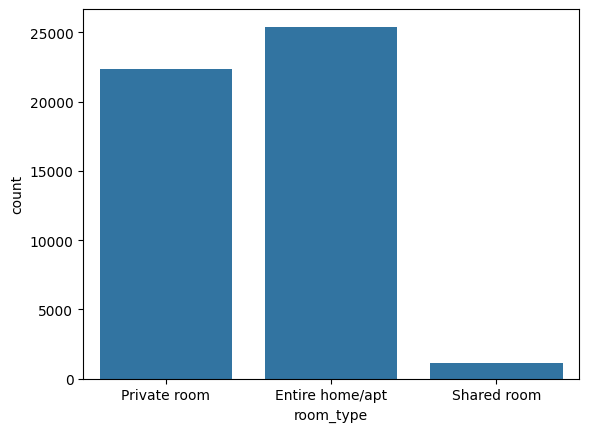

In [12]:
sns.countplot(x='room_type', data=df)

-> Univariate Analysis - Numeric Features

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >, <Axes: >]],
      dtype=object)

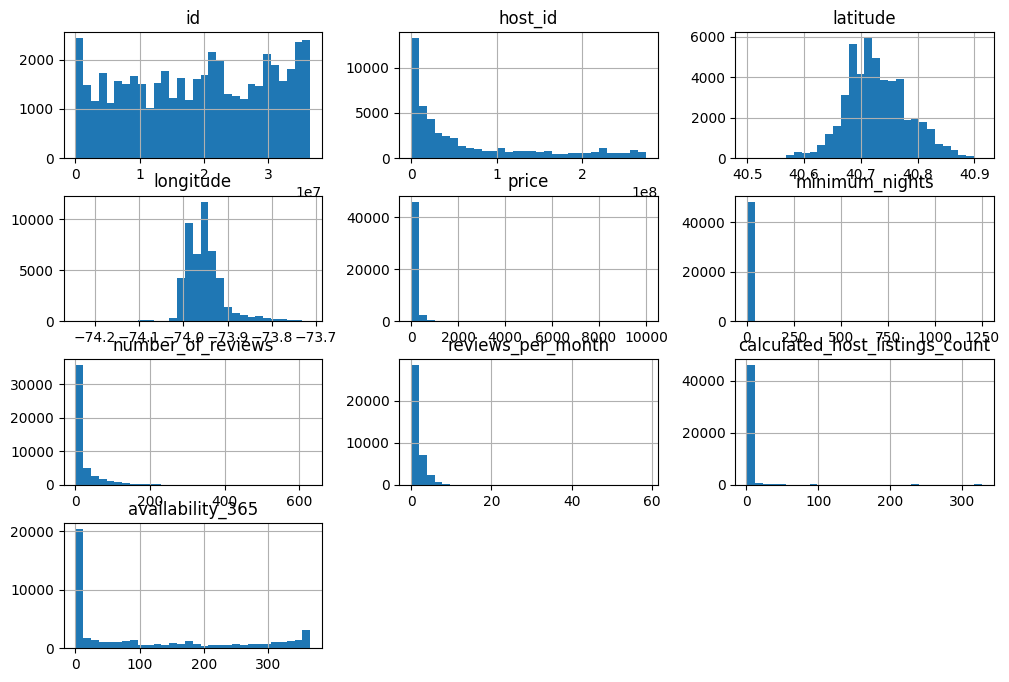

In [13]:
numerical_cols = df.dtypes[df.dtypes != 'object'].index
print(numerical_cols)
df[numerical_cols].hist(bins=30, figsize=(12, 8))

here the `id`, `host_id` is not put any impact in predictions so we don't take these columns as a `numeric_cols`

In [14]:
numerical_cols = ['price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365']

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

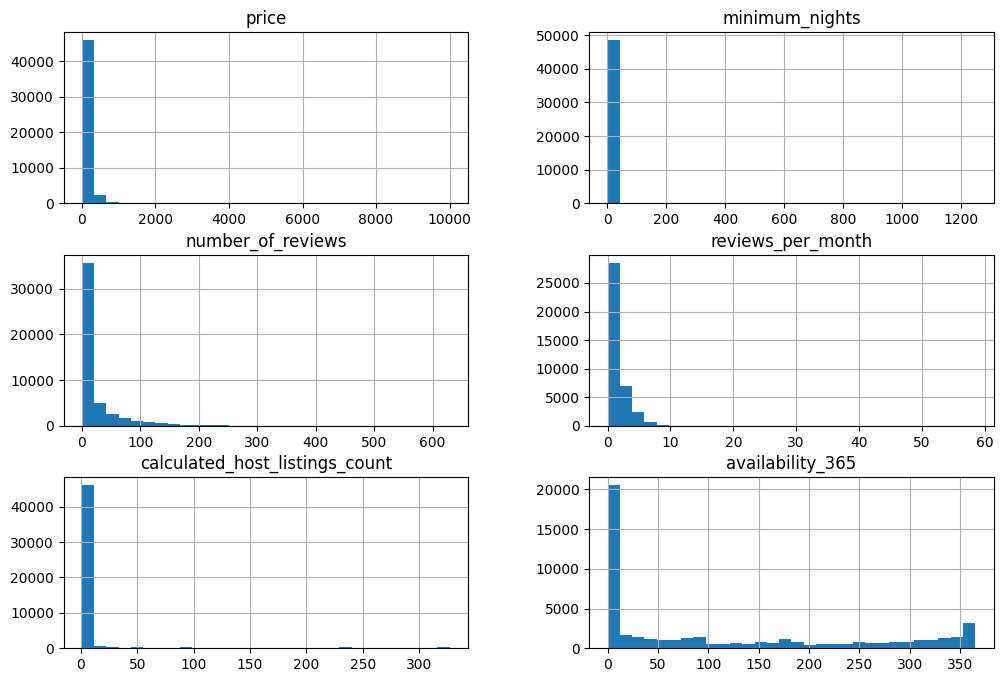

In [15]:
df[numerical_cols].hist(bins=30, figsize=(12, 8))

-> Univariate Analysis - Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

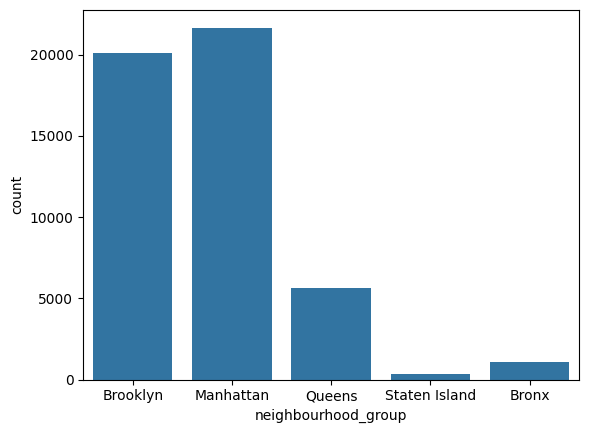

In [16]:
sns.countplot(data=df, x='neighbourhood_group')

-> Bivariate Analysis - Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

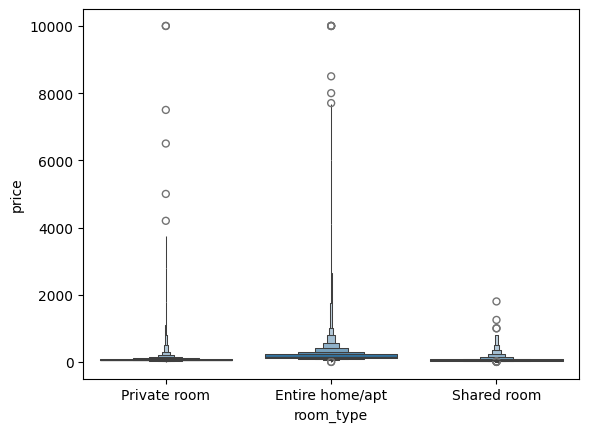

In [17]:
sns.boxenplot(x='room_type', y='price', data=df)

-> Correlation Between Numeric Features

<Axes: >

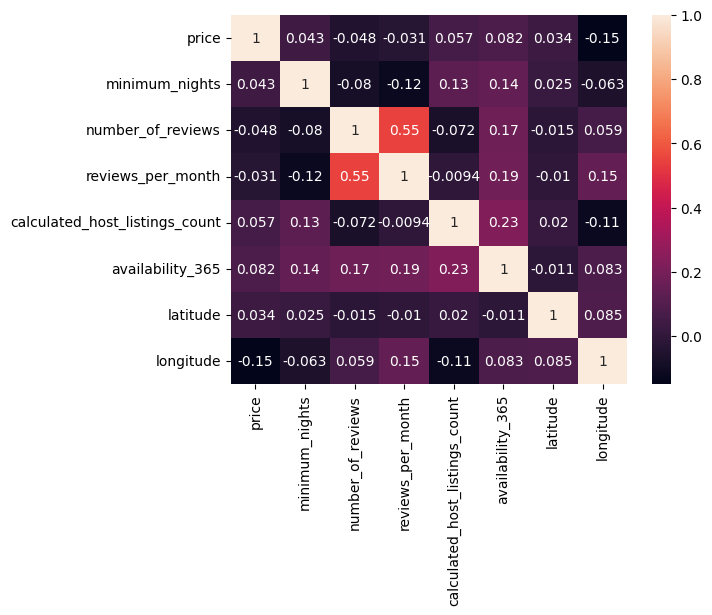

In [18]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr, annot=True)

-> Geographic Distribution 

<Axes: xlabel='longitude', ylabel='latitude'>

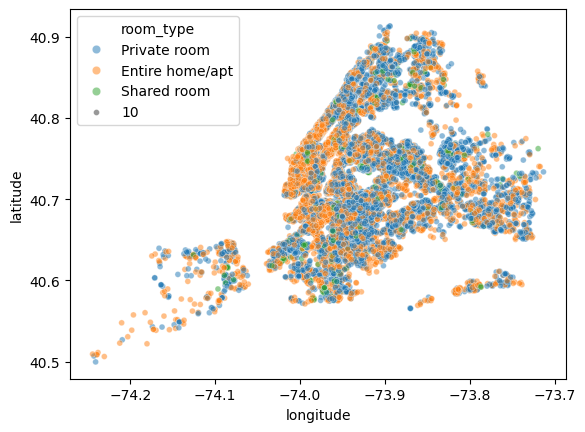

In [19]:
sns.scatterplot(x='longitude', y='latitude', data=df, hue='room_type', alpha=0.5, size=10)

### Data Cleaning and Feature Engineering 

In [20]:
# 1. Drop unnecessary columns
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

# 2. Handle missing values - no reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)


In [21]:
# 3. Cap Extreme outliers instead of deleting rows.
price_cap = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)


In [22]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

### Train / Test Split

We hold out 20% of the data as the **test set** that never touched during model selection or tuning - it is only used once, at the very end, to report the final, honest performance. `stratify=y` keeps the same class proportions in both splits, which matters because the target is imbalanced.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Preprocessing: `ColumnTransformer` + `Pipeline`

In [24]:
df_clean[numerical_cols].skew()

price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.300723
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

In [25]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [26]:
numerical_cols = [  'latitude', 
                    'longitude', 
                    'price',
                    'minimum_nights',
                    'number_of_reviews',
                    'reviews_per_month',
                    'calculated_host_listings_count',
                    'availability_365'
                ]

categorical_cols = ['neighbourhood_group', 'neighbourhood']


# 1. Pipeline for numerical features
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('skewness', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])


# 2. Pipeline for categorical features
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('numerical', numeric_pipeline, numerical_cols),
    ('categorical', categorical_pipeline, categorical_cols)
])

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Trying Multiple Algorithms 

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [33]:
# class_weights = "Balanced" means the model to pay more attention to the minority class

models = {
    "LogisticRegression" : LogisticRegression(class_weight='balanced', random_state=42),
    "DecisionTree" : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "RandomForest" : RandomForestClassifier(class_weight='balanced', random_state=42),
    "GradientBoosting" : GradientBoostingClassifier(random_state=42)
}


for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Accuracy alone can be misleading in imbalanced datasets, so we use macro f1. Both: plain accuracy and macro f1 (which treats every class equally)
    accuracy = cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy')
    macro_f1 = cross_val_score(pipe, X_train, y_train, cv=3, scoring='f1_macro')
    
    
    print(f"{name} - Accuracy: {accuracy.mean():.4f}, Macro F1: {macro_f1.mean():.4f}")
    

LogisticRegression - Accuracy: 0.7299, Macro F1: 0.5789
DecisionTree - Accuracy: 0.7838, Macro F1: 0.6519
RandomForest - Accuracy: 0.8516, Macro F1: 0.7123
GradientBoosting - Accuracy: 0.8493, Macro F1: 0.7055
